In [8]:
import sys
!{sys.executable} -m pip install matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

## Load Dataset

In [10]:
import pandas as pd
import numpy as np

# قراءة الداتا سيت
df = pd.read_csv("D:\House_Price_Project\data\house_prices.csv")

print("Shape:", df.shape)
display(df.head())
df.info()
display(df.describe())

# فحص القيم المفقودة لكل عمود
missing = df.isna().mean().sort_values(ascending=False)
print("Missing values ratio:\n", missing)

Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


Missing values ratio:
 Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64


In [11]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='str')

In [12]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [13]:
(df.isnull().sum()/len(df))*100

Index                  0.000000
Title                  0.000000
Description            1.612000
Amount(in rupees)      0.000000
Price (in rupees)      9.419776
location               0.000000
Carpet Area           43.018488
Status                 0.327946
Floor                  3.773776
Transaction            0.044259
Furnishing             1.544811
facing                37.451408
overlooking           43.425354
Society               58.485264
Bathroom               0.441527
Balcony               26.094352
Car Parking           55.114621
Ownership             34.936624
Super Area            57.422506
Dimensions           100.000000
Plot Area            100.000000
dtype: float64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

Index                187531
Title                 32446
Description           65634
Amount(in rupees)      1561
Price (in rupees)     10958
location                 81
Carpet Area            2758
Status                    1
Floor                   947
Transaction               4
Furnishing                3
facing                    8
overlooking              19
Society               10376
Bathroom                 11
Balcony                  11
Car Parking             229
Ownership                 4
Super Area             2976
Dimensions                0
Plot Area                 0
dtype: int64

## Data Summary

The dataset contains around 187 thousand rows.

The dataset has both numerical and categorical features.

Some columns contain many missing values.

The target variable is Amount(in rupees).

The dataset requires data cleaning before training.

# Data Cleaning

In [16]:
df_clean = df.copy()

In [17]:
df_clean.drop(columns=[
    "Index",
    "Title",
    "Description",
    "Dimensions",
    "Plot Area"
], inplace=True)

In [18]:
df_clean.columns

Index(['Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area',
       'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking',
       'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership',
       'Super Area'],
      dtype='str')

In [19]:
def clean_price(price):

    if pd.isna(price):
        return np.nan

    price = str(price).strip()

    if "Lac" in price:
        return float(price.replace("Lac","")) * 100000

    elif "Cr" in price:
        return float(price.replace("Cr","")) * 10000000

    else:
        return np.nan

In [20]:
df_clean["price_clean"] = df_clean["Amount(in rupees)"].apply(clean_price)

In [21]:
df_clean[
    ["Amount(in rupees)",
     "price_clean"]
].head(10)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [22]:
def clean_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area)

    number = re.findall(r"\d+\.?\d*", area)

    if len(number)==0:
        return np.nan

    number=float(number[0])

    if "sqm" in area.lower():
        number*=10.764

    return number

In [23]:
df_clean["carpet_area_sqft"] = df_clean["Carpet Area"].apply(clean_area)

In [24]:
df_clean[
[
"Carpet Area",
"carpet_area_sqft"
]
].head(10)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [25]:
def clean_floor(floor):

    if pd.isna(floor):
        return np.nan

    floor=str(floor)

    match=re.search(r"\d+",floor)

    if match:
        return int(match.group())

    if "Ground" in floor:
        return 0

    return np.nan

In [26]:
df_clean["Floor"]=df_clean["Floor"].apply(clean_floor)

In [27]:
df_clean["Floor"].head(20)

0     10.0
1      3.0
2     10.0
3      1.0
4     20.0
5      2.0
6      4.0
7      7.0
8      2.0
9      3.0
10     6.0
11    16.0
12     8.0
13    18.0
14     2.0
15    10.0
16     5.0
17     4.0
18    20.0
19     3.0
Name: Floor, dtype: float64

In [28]:
df_clean.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,price_clean,carpet_area_sqft
0,42 Lac,6000.0,thane,500 sqft,Ready to Move,10.0,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,4200000.0,500.0
1,98 Lac,13799.0,thane,473 sqft,Ready to Move,3.0,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,9800000.0,473.0
2,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10.0,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,14000000.0,779.0
3,25 Lac,NaN,thane,530 sqft,Ready to Move,1.0,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,2500000.0,530.0
4,1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20.0,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,16000000.0,635.0


In [29]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Amount(in rupees)  187531 non-null  str    
 1   Price (in rupees)  169866 non-null  float64
 2   location           187531 non-null  str    
 3   Carpet Area        106858 non-null  str    
 4   Status             186916 non-null  str    
 5   Floor              180453 non-null  float64
 6   Transaction        187448 non-null  str    
 7   Furnishing         184634 non-null  str    
 8   facing             117298 non-null  str    
 9   overlooking        106095 non-null  str    
 10  Society            77853 non-null   str    
 11  Bathroom           186703 non-null  str    
 12  Balcony            138596 non-null  str    
 13  Car Parking        84174 non-null   str    
 14  Ownership          122014 non-null  str    
 15  Super Area         79846 non-null   str    
 16  price_clean  

In [30]:
df_clean.drop(columns=[
    "Amount(in rupees)",
    "Price (in rupees)",
    "Carpet Area",
    "Society",
    "Super Area"
], inplace=True)

In [31]:
df_clean.isnull().sum()

location                 0
Status                 615
Floor                 7078
Transaction             83
Furnishing            2897
facing               70233
overlooking          81436
Bathroom               828
Balcony              48935
Car Parking         103357
Ownership            65517
price_clean           9684
carpet_area_sqft     80673
dtype: int64

In [32]:
df_clean["Bathroom"] = pd.to_numeric(df_clean["Bathroom"], errors="coerce")

df_clean["Balcony"] = pd.to_numeric(df_clean["Balcony"], errors="coerce")

In [33]:
numeric_columns = [
    "Floor",
    "Bathroom",
    "Balcony",
    "carpet_area_sqft"
]

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [34]:
categorical_columns = [
    "Status",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Ownership"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [35]:
df_clean = df_clean.dropna(subset=["price_clean"])

In [36]:
df_clean.isnull().sum()

location                0
Status                  0
Floor                   0
Transaction             0
Furnishing              0
facing                  0
overlooking             0
Bathroom                0
Balcony                 0
Car Parking         95912
Ownership               0
price_clean             0
carpet_area_sqft        0
dtype: int64

In [37]:
df_clean["location"].nunique()

81

In [38]:
df_clean["Furnishing"].value_counts()

Furnishing
Semi-Furnished    84935
Unfurnished       73491
Furnished         19421
Name: count, dtype: int64

EDA (Visualization)

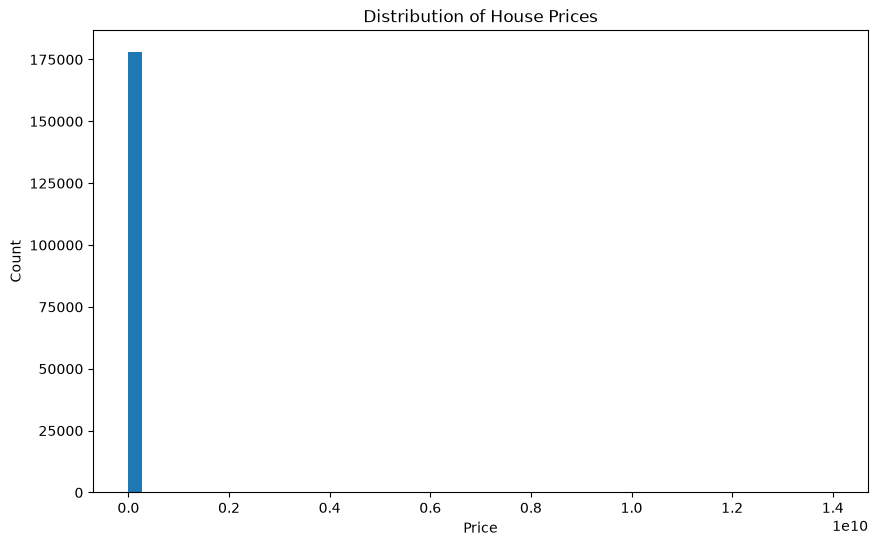

In [39]:
plt.figure(figsize=(10,6))

plt.hist(df_clean["price_clean"], bins=50)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

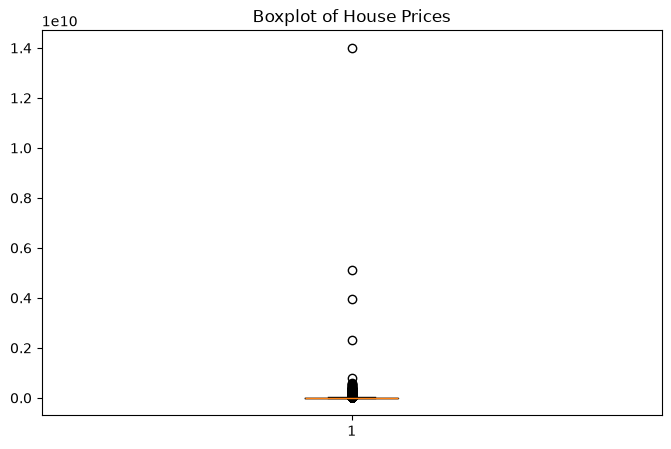

In [40]:
plt.figure(figsize=(8,5))

plt.boxplot(df_clean["price_clean"])

plt.title("Boxplot of House Prices")

plt.show()

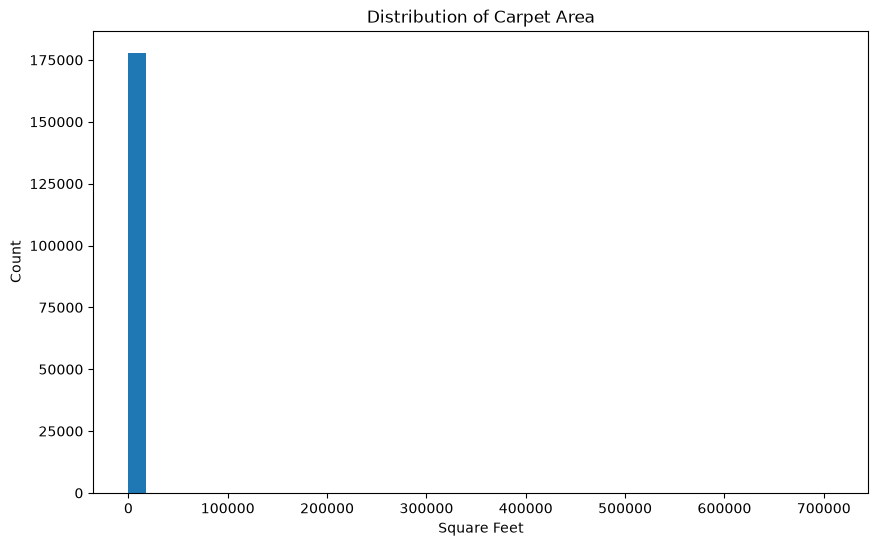

In [41]:
plt.figure(figsize=(10,6))

plt.hist(df_clean["carpet_area_sqft"], bins=40)

plt.title("Distribution of Carpet Area")

plt.xlabel("Square Feet")

plt.ylabel("Count")

plt.show()

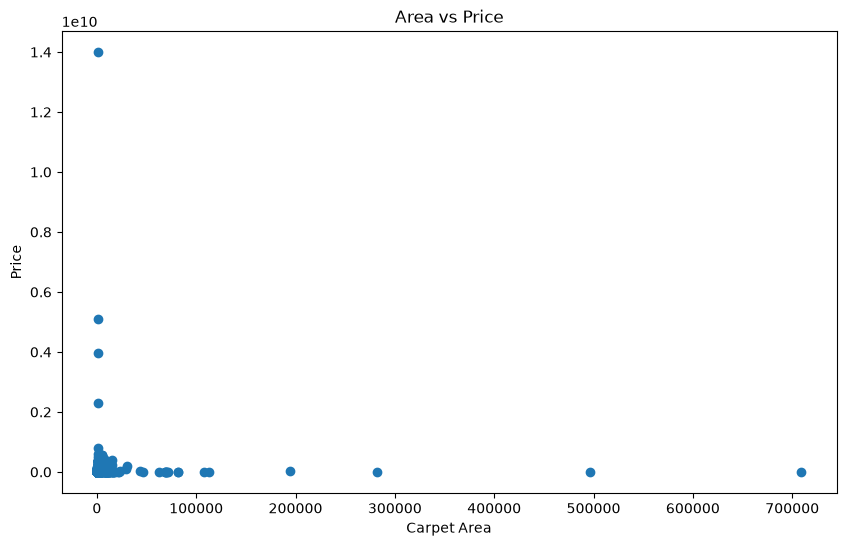

In [42]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["carpet_area_sqft"],
    df_clean["price_clean"]
)

plt.xlabel("Carpet Area")

plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

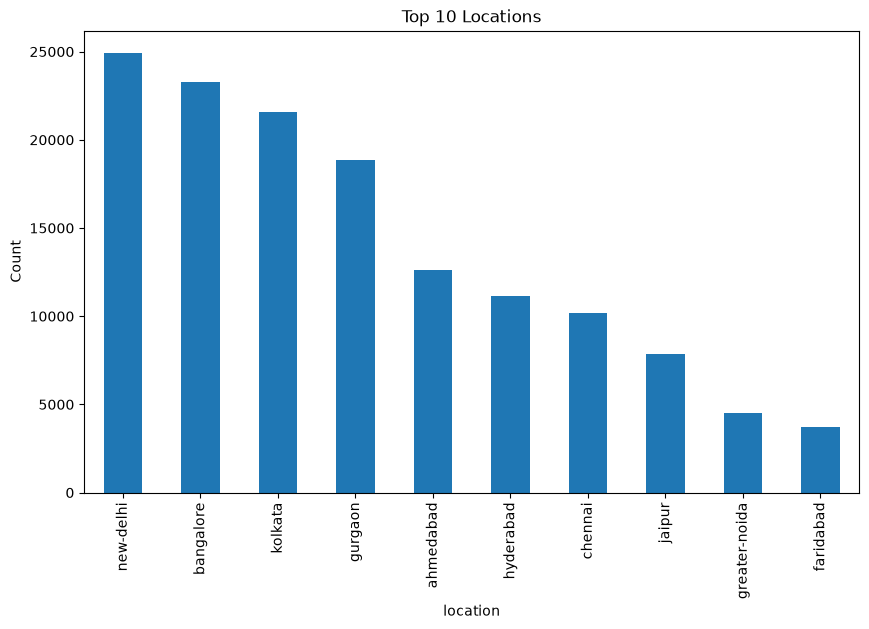

In [43]:
top_locations = df_clean["location"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_locations.plot(kind="bar")

plt.title("Top 10 Locations")

plt.ylabel("Count")

plt.show()

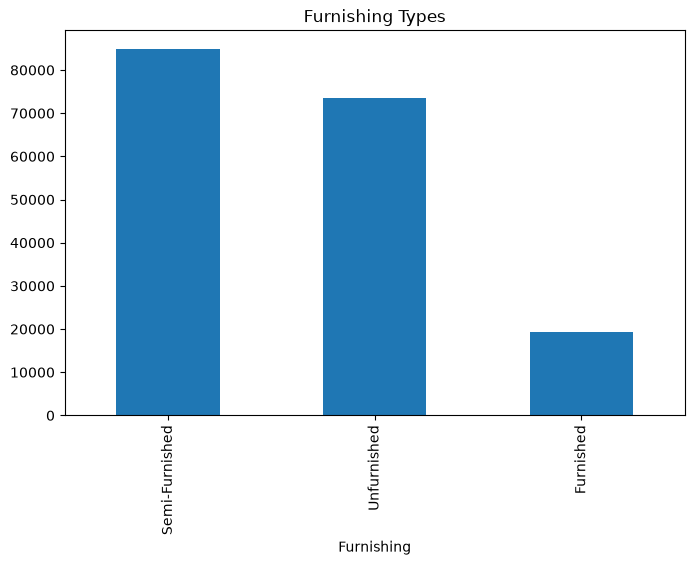

In [44]:
plt.figure(figsize=(8,5))

df_clean["Furnishing"].value_counts().plot(kind="bar")

plt.title("Furnishing Types")

plt.show()

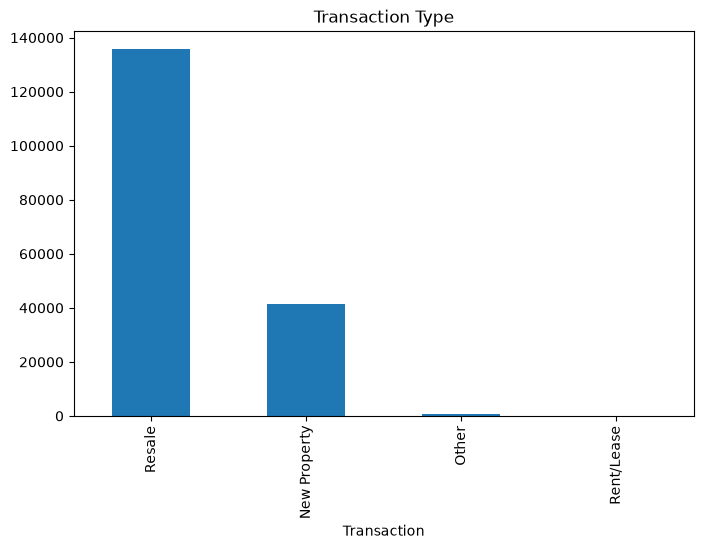

In [45]:
plt.figure(figsize=(8,5))

df_clean["Transaction"].value_counts().plot(kind="bar")

plt.title("Transaction Type")

plt.show()

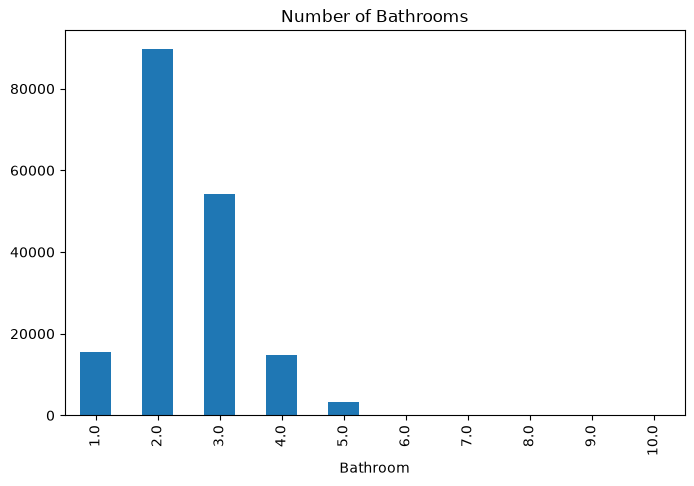

In [46]:
plt.figure(figsize=(8,5))

df_clean["Bathroom"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Bathrooms")

plt.show()

In [47]:
numeric_df = df_clean.select_dtypes(include=np.number)

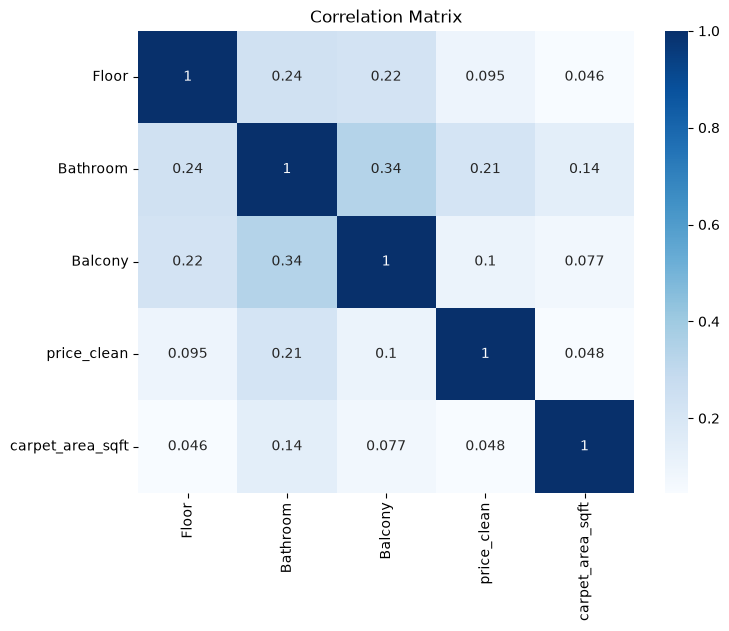

In [48]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

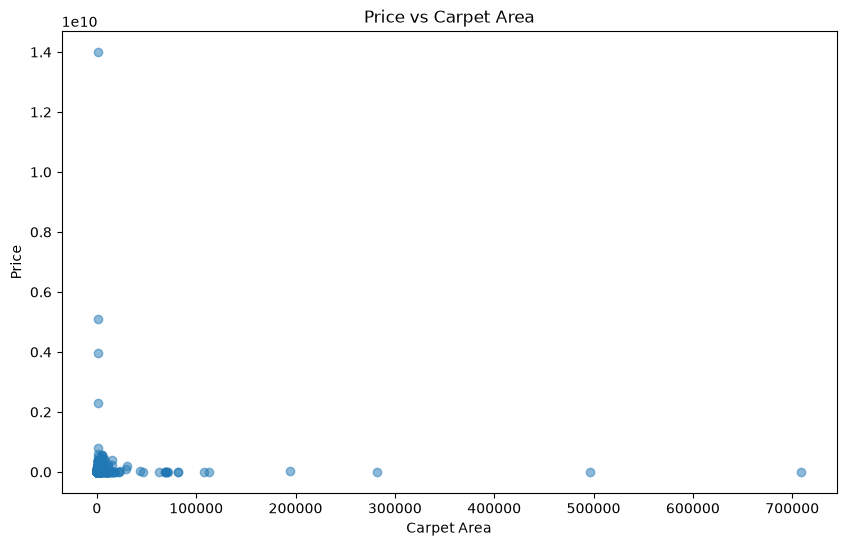

In [49]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["carpet_area_sqft"],
    df_clean["price_clean"],
    alpha=0.5
)

plt.title("Price vs Carpet Area")

plt.xlabel("Carpet Area")

plt.ylabel("Price")

plt.show()

In [50]:
df_clean["Car Parking"].value_counts().head(20)

Car Parking
1 Covered      37760
1 Covered,     16893
2 Covered      10020
1 Open          7697
2 Covered,      3968
2 Open          2560
10 Open          843
34 Covered       573
3 Covered        394
402 Covered      317
3 Covered,       138
4 Covered        109
5 Covered         33
3 Open            32
4 Covered,        27
4 Open            26
15 Covered        24
5 Open            23
6 Covered         23
8 Covered         22
Name: count, dtype: int64

In [51]:
Q1 = df_clean["price_clean"].quantile(0.25)
Q3 = df_clean["price_clean"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [52]:
df_clean = df_clean[
    (df_clean["price_clean"] >= lower) &
    (df_clean["price_clean"] <= upper)
]

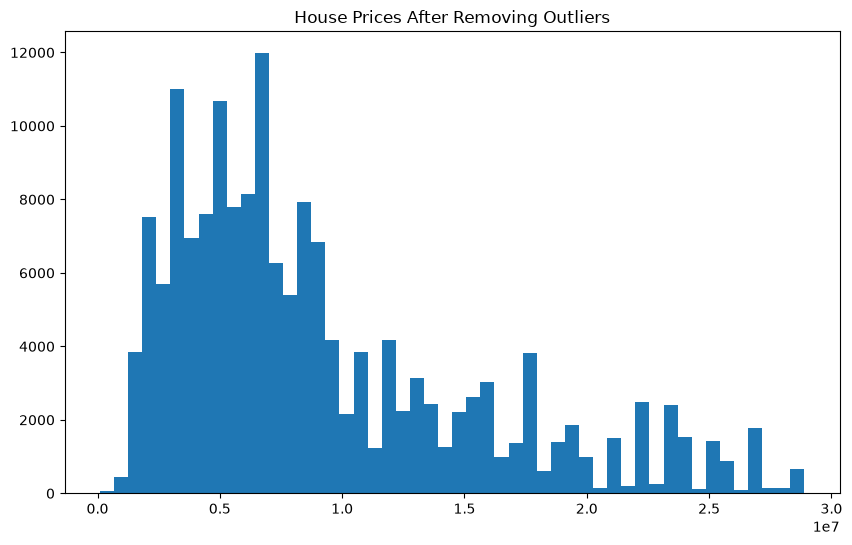

In [53]:
plt.figure(figsize=(10,6))

plt.hist(df_clean["price_clean"], bins=50)

plt.title("House Prices After Removing Outliers")

plt.show()

In [54]:
def clean_parking(x):
    if pd.isna(x):
        return np.nan

    import re

    match = re.search(r"\d+", str(x))

    if match:
        return int(match.group())

    return np.nan

In [55]:
df_clean["Car Parking"] = df_clean["Car Parking"].apply(clean_parking)

In [56]:
df_clean["Car Parking"] = df_clean["Car Parking"].fillna(
    df_clean["Car Parking"].median()
)

In [57]:
df_clean["Car Parking"].value_counts().head(10)

Car Parking
1.0      154654
2.0        8401
10.0        866
34.0        573
402.0       315
3.0         191
4.0          57
5.0          40
15.0         29
6.0          27
Name: count, dtype: int64

In [58]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 165564 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   location          165564 non-null  str    
 1   Status            165564 non-null  str    
 2   Floor             165564 non-null  float64
 3   Transaction       165564 non-null  str    
 4   Furnishing        165564 non-null  str    
 5   facing            165564 non-null  str    
 6   overlooking       165564 non-null  str    
 7   Bathroom          165564 non-null  float64
 8   Balcony           165564 non-null  float64
 9   Car Parking       165564 non-null  float64
 10  Ownership         165564 non-null  str    
 11  price_clean       165564 non-null  float64
 12  carpet_area_sqft  165564 non-null  float64
dtypes: float64(6), str(7)
memory usage: 17.7 MB


In [59]:
df_clean.isnull().sum()

location            0
Status              0
Floor               0
Transaction         0
Furnishing          0
facing              0
overlooking         0
Bathroom            0
Balcony             0
Car Parking         0
Ownership           0
price_clean         0
carpet_area_sqft    0
dtype: int64

# Part 1 : Features & Target

In [60]:
X = df_clean.drop("price_clean", axis=1)

y = df_clean["price_clean"]

print(X.shape)
print(y.shape)

(165564, 12)
(165564,)


# Part 2 : Train Test Split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

print(X_train.shape)
print(X_test.shape)

(132451, 12)
(33113, 12)


# Part 3 : Numerical & Categorical Columns

In [62]:
numeric_features = X.select_dtypes(include=np.number).columns

categorical_features = X.select_dtypes(include="object").columns

print(numeric_features)

print(categorical_features)

Index(['Floor', 'Bathroom', 'Balcony', 'Car Parking', 'carpet_area_sqft'], dtype='str')
Index(['location', 'Status', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Ownership'],
      dtype='str')


# Part 4 : Numerical Pipeline

In [63]:
numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

# Part 5 : Categorical Pipeline

In [64]:
categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

# Part 6 : Column Transformer

In [65]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numeric_features),

        ("cat", categorical_transformer, categorical_features)

    ]

)

# Part 7 : Linear Regression

In [66]:
linear_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", LinearRegression())

    ]

)

In [67]:
X_train.dtypes

location                str
Status                  str
Floor               float64
Transaction             str
Furnishing              str
facing                  str
overlooking             str
Bathroom            float64
Balcony             float64
Car Parking         float64
Ownership               str
carpet_area_sqft    float64
dtype: object

In [68]:
cat_cols = X_train.select_dtypes(include="str").columns

X_train[cat_cols] = X_train[cat_cols].astype(object)
X_test[cat_cols] = X_test[cat_cols].astype(object)

In [69]:
# تحويل كل الأعمدة النصية إلى object
for col in X_train.select_dtypes(include=["string", "str"]).columns:
    X_train[col] = X_train[col].astype(object)
    X_test[col] = X_test[col].astype(object)

print(X_train.dtypes)

location             object
Status               object
Floor               float64
Transaction          object
Furnishing           object
facing               object
overlooking          object
Bathroom            float64
Balcony             float64
Car Parking         float64
Ownership            object
carpet_area_sqft    float64
dtype: object


In [70]:
# تحديد الأعمدة من جديد
numerical_cols = X_train.select_dtypes(include=['int64','float64']).columns
categorical_cols = X_train.select_dtypes(include=['object','str','string']).columns

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: Index(['Floor', 'Bathroom', 'Balcony', 'Car Parking', 'carpet_area_sqft'], dtype='str')
Categorical: Index(['location', 'Status', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Ownership'],
      dtype='str')


In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler', StandardScaler())
         ]),
         numerical_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('onehot', OneHotEncoder(handle_unknown='ignore'))
         ]),
         categorical_cols)
    ]
)

In [72]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [73]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 132451 entries, 16559 to 141255
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   location          132451 non-null  object 
 1   Status            132451 non-null  object 
 2   Floor             132451 non-null  float64
 3   Transaction       132451 non-null  object 
 4   Furnishing        132451 non-null  object 
 5   facing            132451 non-null  object 
 6   overlooking       132451 non-null  object 
 7   Bathroom          132451 non-null  float64
 8   Balcony           132451 non-null  float64
 9   Car Parking       132451 non-null  float64
 10  Ownership         132451 non-null  object 
 11  carpet_area_sqft  132451 non-null  float64
dtypes: float64(5), object(7)
memory usage: 13.1+ MB


In [74]:
y_train.dtype

dtype('float64')

In [75]:
y_train.head()

16559     12900000.0
34570      8630000.0
80403      5600000.0
73883      9300000.0
162331     8700000.0
Name: price_clean, dtype: float64

In [76]:
X_train = X_train.copy()
X_test = X_test.copy()

for col in X_train.columns:
    if X_train[col].dtype.name == "string":
        X_train[col] = X_train[col].astype(object)
        X_test[col] = X_test[col].astype(object)

y_train = y_train.astype(float)

In [77]:
print(numerical_cols)
print(categorical_cols)

Index(['Floor', 'Bathroom', 'Balcony', 'Car Parking', 'carpet_area_sqft'], dtype='str')
Index(['location', 'Status', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Ownership'],
      dtype='str')


In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

numerical_cols = ['Floor', 'Bathroom', 'Balcony', 'Car Parking', 'carpet_area_sqft']

categorical_cols = [
    'location',
    'Status',
    'Transaction',
    'Furnishing',
    'facing',
    'overlooking',
    'Ownership'
]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])


linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])


linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Floor', 'Bathroom',
                                                   'Balcony', 'Car Parking',
                                                   'carpet_area_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location', 'Status',
                                                   'Transaction', 'Furnishing',
                                                   'facing', 'overlooking',
                                                   'Ownership'])])),
                ('model', LinearRegression())])

In [79]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler', StandardScaler())
         ]),
         numerical_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('onehot', OneHotEncoder(handle_unknown='ignore'))
         ]),
         categorical_cols)
    ]
)


linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Part 8 : Train

In [80]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Floor', 'Bathroom',
                                                   'Balcony', 'Car Parking',
                                                   'carpet_area_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location', 'Status',
                                                   'Transaction', 'Furnishing',
                                                   'facing', 'overlooking',
                                                   'Ownership'])])),
                ('model', LinearRegression())])

# Part 9 : Prediction

In [81]:
y_pred_linear = linear_model.predict(X_test)

# Part 10 : Evaluation

In [82]:
mae = mean_absolute_error(y_test, y_pred_linear)

mse = mean_squared_error(y_test, y_pred_linear)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

Linear Regression
MAE : 2919280.1839537094
RMSE : 3931853.977598104
R2 : 0.6172376744744786


# Random Forest

In [83]:
rf_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        (

            "model",

            RandomForestRegressor(

                n_estimators=150,

                random_state=42

            )

        )

    ]

)

In [84]:
X_train['location'].nunique()

81

# Train

In [ ]:
rf_model.fit(X_train, y_train)

# Prediction

In [ ]:
y_pred_rf = rf_model.predict(X_test)

# Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred_rf)

mse = mean_squared_error(y_test, y_pred_rf)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

# Compare Models

In [ ]:
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest"

    ],

    "MAE":[

        mean_absolute_error(y_test,y_pred_linear),

        mean_absolute_error(y_test,y_pred_rf)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test,y_pred_linear)),

        np.sqrt(mean_squared_error(y_test,y_pred_rf))

    ],

    "R2":[

        r2_score(y_test,y_pred_linear),

        r2_score(y_test,y_pred_rf)

    ]

})

results

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison (R2 Score)")

plt.ylabel("R2")

plt.show()

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    y_pred_rf,

    alpha=0.5

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

# Save Model

In [ ]:
joblib.dump(

    rf_model,

    "house_price_model.pkl"

)

# Test Model

In [ ]:
sample = X.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted Price :", prediction[0])

print("Actual Price :", y.iloc[0])

In [ ]:
print("Model Score :", linear_model.score(X_test,y_test))

In [ ]:
print("Model Score :", rf_model.score(X_test,y_test))

# 1️⃣ مقارنة بين Actual و Predicted

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

# 2️⃣ Residual Plot

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_rf,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# 3️⃣ Feature Importance

In [ ]:
encoder = preprocessor.named_transformers_["cat"]["encoder"]

cat_features = encoder.get_feature_names_out(categorical_features)

feature_names = np.concatenate(
    [
        numeric_features,
        cat_features
    ]
)

importance = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(

    importance_df.head(15)["Feature"],

    importance_df.head(15)["Importance"]

)

plt.title("Top Important Features")

plt.gca().invert_yaxis()

plt.show()

# 4 Load Model

In [ ]:
loaded_model = joblib.load(
    "house_price_model.pkl"
)

# Prediction

In [ ]:
sample = X.iloc[[20]]

prediction = loaded_model.predict(sample)

print(prediction)

# Conclusion

• Data cleaning was successfully completed.

• Missing values were handled.

• Outliers were removed.

• Features were encoded and scaled.

• Two regression models were trained.

• Random Forest achieved better performance than Linear Regression.

# • The trained model was saved using Joblib and is ready for deployment.

In [ ]:
%who